# Step 1 : Project Overview (Markdown)

# AI Generated Review Detection using Machine Learning and MLOps

## Project Overview

This project builds a machine learning model capable of distinguishing
between AI-generated reviews and human-written reviews.

The project follows an end-to-end MLOps workflow including:

- Data Analysis
- Data Cleaning
- Text Preprocessing
- Feature Engineering
- Machine Learning
- Hyperparameter Tuning
- MLflow Experiment Tracking
- Model Saving
- Prediction Pipeline

Dataset Source

Kaggle:
Fake Reviews Dataset

Target Variable

CG → AI Generated Review

OR → Human Written Review

## Step 2 : Import Libraries

In [4]:
!pip install contractions emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.2 MB/s eta 0:00:00


In [5]:
"""
Import required libraries
"""

import re
import time
import string
import warnings

import joblib
import contractions
import emoji
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Step 3 : Load Dataset

In [7]:
"""
Load dataset
"""

df = pd.read_csv("fake_reviews_dataset.csv")

print("Dataset Loaded Successfully\n")

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

display(df.head())

Dataset Loaded Successfully

Rows    : 40432
Columns : 4


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfortable. I love it!Very pretty"
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I've had mine for a couple of years"
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and feel of this pillow.
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it is a great product for the price! I"
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the set for two months now and have not been


## Step 4 : Exploratory Data Analysis (EDA)

In [9]:
"""
Basic dataset analysis
"""

print("Dataset Information\n")

display(df.info())

print("\nMissing Values\n")

display(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

print("\nRemove Duplicate Rows:\n")
df.drop_duplicates(inplace=True)

df.reset_index(drop=True, inplace=True)

print(df.shape)

print("\nStatistical Summary\n")

display(df.describe(include="all"))

print("\nUnique Categories :", df["category"].nunique())

print("\nCategories\n")

for category in sorted(df["category"].unique()):
    print(category)

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


None


Missing Values



,0
category,0
rating,0
label,0
text_,0



Duplicate Rows : 12

Remove Duplicate Rows:

(40420, 4)

Statistical Summary



,category,rating,label,text_
count,40420,40420.000000,40420,40420
unique,10,NaN,2,40412
top,Kindle_Store_5,NaN,OR,These are very comfortable. They have the wide width which is perfect. They are warm and
freq,4728,NaN,20215,2
mean,NaN,4.256358,NaN,NaN
std,NaN,1.144452,NaN,NaN
min,NaN,1.000000,NaN,NaN
25%,NaN,4.000000,NaN,NaN
50%,NaN,5.000000,NaN,NaN
75%,NaN,5.000000,NaN,NaN



Unique Categories : 10

Categories

Books_5
Clothing_Shoes_and_Jewelry_5
Electronics_5
Home_and_Kitchen_5
Kindle_Store_5
Movies_and_TV_5
Pet_Supplies_5
Sports_and_Outdoors_5
Tools_and_Home_Improvement_5
Toys_and_Games_5


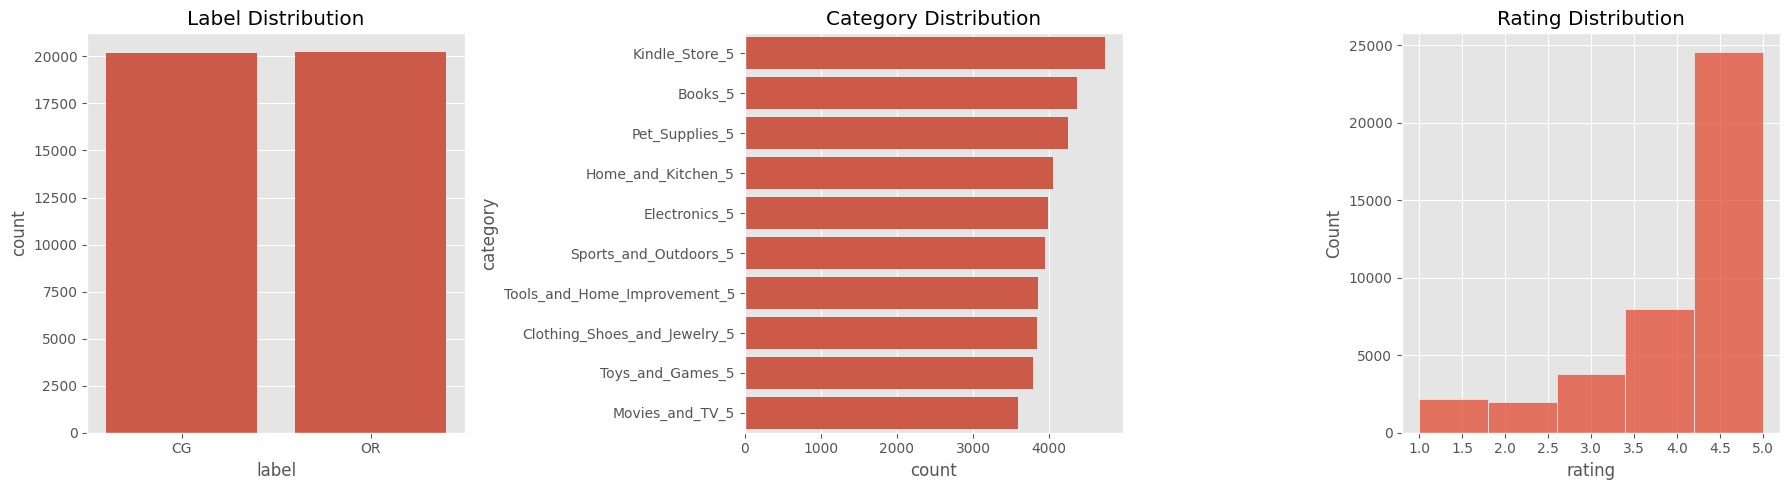

In [10]:
"""
Visualize dataset
"""

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(
    data=df,
    x="label",
    ax=axes[0]
)

axes[0].set_title("Label Distribution")

sns.countplot(
    data=df,
    y="category",
    order=df["category"].value_counts().index,
    ax=axes[1]
)

axes[1].set_title("Category Distribution")

sns.histplot(
    data=df,
    x="rating",
    bins=5,
    ax=axes[2]
)

axes[2].set_title("Rating Distribution")

plt.tight_layout()

plt.show()

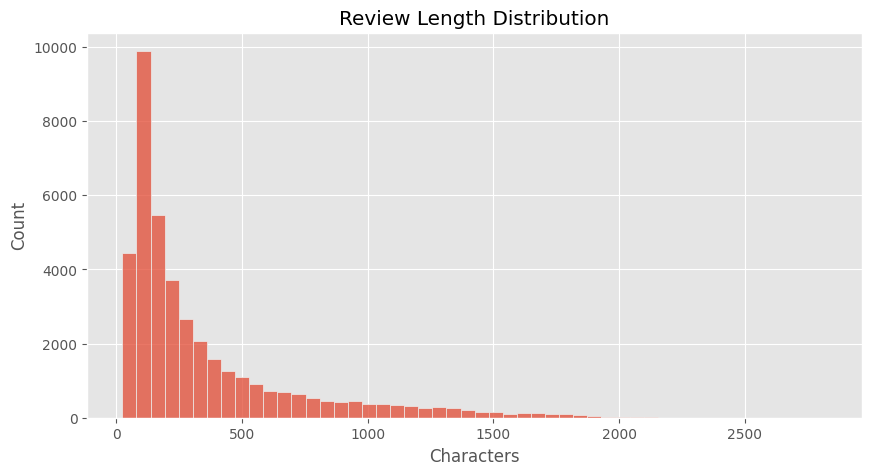

count    40420.000000
mean       351.321227
std        369.850284
min         24.000000
25%        107.000000
50%        198.000000
75%        439.000000
max       2827.000000
Name: review_length, dtype: float64


In [11]:
"""
Review length analysis
"""

df["review_length"] = df["text_"].astype(str).apply(len)

plt.figure(figsize=(10,5))

sns.histplot(
    df["review_length"],
    bins=50
)

plt.title("Review Length Distribution")

plt.xlabel("Characters")

plt.show()

print(df["review_length"].describe())

## Step 5 : Data Cleaning

In [12]:
"""
Clean dataset
"""

clean_df = df.copy()

print("Original Shape :", clean_df.shape)

clean_df.dropna(inplace=True)

clean_df.drop_duplicates(inplace=True)

clean_df = clean_df[
    clean_df["text_"].str.strip() != ""
]

clean_df.reset_index(
    drop=True,
    inplace=True
)

clean_df["label"] = clean_df["label"].map({
    "CG": 1,
    "OR": 0
})

print("\nClean Dataset Shape :", clean_df.shape)

print("\nLabel Distribution")

display(clean_df["label"].value_counts())

display(clean_df.head())

Original Shape : (40420, 5)

Clean Dataset Shape : (40420, 5)

Label Distribution


,count
label,
0,20215
1,20205


,category,rating,label,text_,review_length
0,Home_and_Kitchen_5,5.0,1,"Love this! Well made, sturdy, and very comfortable. I love it!Very pretty",75
1,Home_and_Kitchen_5,5.0,1,"love it, a great upgrade from the original. I've had mine for a couple of years",80
2,Home_and_Kitchen_5,5.0,1,This pillow saved my back. I love the look and feel of this pillow.,67
3,Home_and_Kitchen_5,1.0,1,"Missing information on how to use it, but it is a great product for the price! I",81
4,Home_and_Kitchen_5,5.0,1,Very nice set. Good quality. We have had the set for two months now and have not been,85


In [13]:
"""
Save cleaned dataset
"""

clean_df.to_csv(
    "clean_dataset.csv",
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


## Step 6 : Text Preprocessing (Markdown)

 # Text Preprocessing

The objective of this step is to clean the review text before converting it
into numerical features.

The preprocessing pipeline includes:

- Convert text to lowercase
- Expand contractions
- Remove HTML tags
- Remove URLs
- Remove email addresses
- Remove emojis
- Remove non-ASCII characters
- Remove numbers
- Remove repeated characters
- Remove punctuation
- Remove extra spaces
- Remove stopwords
- Apply lemmatization

In [14]:
"""
Download required NLTK resources
"""

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

print("NLTK Resources Loaded Successfully")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


NLTK Resources Loaded Successfully


In [15]:
"""
Create text preprocessing function
"""

def clean_text(text):

    text = str(text)

    text = text.lower()

    text = contractions.fix(text)

    text = BeautifulSoup(
        text,
        "html.parser"
    ).get_text()

    text = emoji.replace_emoji(
        text,
        replace=""
    )

    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    text = re.sub(
        r"\S+@\S+",
        "",
        text
    )

    text = re.sub(
        r"\d+",
        "",
        text
    )

    text = re.sub(
        r"[^\x00-\x7F]+",
        " ",
        text
    )

    text = re.sub(
        r"(.)\1{2,}",
        r"\1\1",
        text
    )

    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    words = [
        word
        for word in words
        if len(word) > 1
    ]

    return " ".join(words)

In [16]:
"""
Apply preprocessing on review text
"""

clean_df["clean_review"] = clean_df["text_"].apply(
    clean_text
)

print("Text Preprocessing Completed Successfully")

display(
    clean_df[
        [
            "text_",
            "clean_review"
        ]
    ].head()
)

Text Preprocessing Completed Successfully


,text_,clean_review
0,"Love this! Well made, sturdy, and very comfortable. I love it!Very pretty",love well made sturdy comfortable love itvery pretty
1,"love it, a great upgrade from the original. I've had mine for a couple of years",love great upgrade original mine couple year
2,This pillow saved my back. I love the look and feel of this pillow.,pillow saved back love look feel pillow
3,"Missing information on how to use it, but it is a great product for the price! I",missing information use great product price
4,Very nice set. Good quality. We have had the set for two months now and have not been,nice set good quality set two month


In [17]:
"""
Save dataset after preprocessing
"""

clean_df.to_csv(
    "preprocessed_dataset.csv",
    index=False
)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


## Step 7 : Feature Engineering (Markdown)

# Feature Engineering

Machine learning models cannot process raw text directly.

This step converts the review text and additional information into
numerical features.

Features used:

- TF-IDF representation of review text
- Product category
- Product rating

The final feature matrix combines all three feature groups.

In [18]:
"""
Encode product category using One Hot Encoding
"""

from sklearn.preprocessing import OneHotEncoder

category_encoder = OneHotEncoder(
    handle_unknown="ignore"
)

category_features = category_encoder.fit_transform(
    clean_df[["category"]]
)

print("Category Encoding Completed")

print("Encoded Shape :", category_features.shape)

Category Encoding Completed
Encoded Shape : (40420, 10)


In [19]:
"""
Convert cleaned reviews into TF-IDF features
"""

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(

    max_features=10000,

    ngram_range=(1, 2),

    min_df=5,

    max_df=0.90

)

review_features = tfidf.fit_transform(
    clean_df["clean_review"]
)

print("TF-IDF Vectorization Completed")

print("Review Feature Shape :", review_features.shape)

TF-IDF Vectorization Completed
Review Feature Shape : (40420, 10000)


In [20]:
"""
Prepare rating feature
"""

rating_features = clean_df[
    ["rating"]
].values

print("Rating Feature Shape :", rating_features.shape)

Rating Feature Shape : (40420, 1)


In [21]:
"""
Combine all features into one matrix
"""

from scipy.sparse import hstack

X = hstack([

    review_features,

    category_features,

    rating_features

])

y = clean_df["label"]

print("Feature Engineering Completed")

print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Engineering Completed
Feature Matrix Shape : (40420, 10011)
Target Shape : (40420,)


In [22]:
"""
Save preprocessing artifacts
"""

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

joblib.dump(
    category_encoder,
    "category_encoder.pkl"
)

print("Artifacts Saved Successfully")

Artifacts Saved Successfully


In [23]:
"""
Display final feature summary
"""

print("Final Feature Matrix")

print("Number of Samples :", X.shape[0])

print("Number of Features :", X.shape[1])

print("Target Distribution")

display(y.value_counts())

Final Feature Matrix
Number of Samples : 40420
Number of Features : 10011
Target Distribution


,count
label,
0,20215
1,20205


## Step 8 : Train-Test Split (Markdown)

# Train-Test Split

The dataset is divided into training and testing subsets.

- Training Set : 80%
- Testing Set : 20%

The split is stratified to preserve the class distribution.

In [24]:
"""
Split dataset into training and testing sets
"""

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Train Test Split Completed\n")

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

print(f"\nTraining Shape : {X_train.shape}")
print(f"Testing Shape  : {X_test.shape}")

Train Test Split Completed

Training Samples : 32336
Testing Samples  : 8084

Training Shape : (32336, 10011)
Testing Shape  : (8084, 10011)


## Step 9 : Train Multiple Machine Learning Models (Markdown)

# Machine Learning Model Training

The following baseline models are trained:

- Logistic Regression
- Multinomial Naive Bayes
- Decision Tree

Each model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC
- Training Time
- Prediction Time

In [31]:
"""
Import machine learning models and evaluation metrics
"""

import time

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score

)

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import LinearSVC

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier


results = []

print("Models Imported Successfully")

Models Imported Successfully


In [26]:
"""
Train and evaluate machine learning model
"""

def evaluate_model(model_name, model):

    train_start = time.time()

    model.fit(
        X_train,
        y_train
    )

    training_time = time.time() - train_start

    prediction_start = time.time()

    predictions = model.predict(X_test)

    prediction_time = time.time() - prediction_start

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    if hasattr(model, "predict_proba"):

        probabilities = model.predict_proba(X_test)[:, 1]

        roc_auc = roc_auc_score(
            y_test,
            probabilities
        )

    else:

        decision_scores = model.decision_function(
            X_test
        )

        roc_auc = roc_auc_score(
            y_test,
            decision_scores
        )

    results.append({

        "Model": model_name,

        "Accuracy": round(accuracy, 4),

        "Precision": round(precision, 4),

        "Recall": round(recall, 4),

        "F1 Score": round(f1, 4),

        "ROC AUC": round(roc_auc, 4),

        "Training Time": round(training_time, 4),

        "Prediction Time": round(prediction_time, 4)

    })

    print(f"{model_name} Training Completed")

In [27]:
"""
Train Logistic Regression
"""

logistic_model = LogisticRegression(

    max_iter=1000,

    random_state=42

)

evaluate_model(

    "Logistic Regression",

    logistic_model

)

Logistic Regression Training Completed


In [28]:
"""
Train Multinomial Naive Bayes
"""

naive_bayes_model = MultinomialNB()

evaluate_model(

    "Multinomial Naive Bayes",

    naive_bayes_model

)

Multinomial Naive Bayes Training Completed


In [29]:
"""
Train Decision Tree
"""

decision_tree_model = DecisionTreeClassifier(

    random_state=42

)

evaluate_model(

    "Decision Tree",

    decision_tree_model

)

Decision Tree Training Completed


In [32]:
"""
Train Random Forest
"""

random_forest_model = RandomForestClassifier(

    n_estimators=200,

    random_state=42,

    n_jobs=-1

)

evaluate_model(

    "Random Forest",

    random_forest_model

)

Random Forest Training Completed


In [33]:
"""
Train Linear Support Vector Machine
"""

linear_svm_model = LinearSVC(

    random_state=42,

    max_iter=5000

)

evaluate_model(

    "Linear SVM",

    linear_svm_model

)

Linear SVM Training Completed


In [34]:
"""
Train XGBoost
"""

xgboost_model = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42,

    n_estimators=200,

    learning_rate=0.1,

    max_depth=6,

    n_jobs=-1

)

evaluate_model(

    "XGBoost",

    xgboost_model

)

XGBoost Training Completed


In [35]:
"""
Train LightGBM
"""

lightgbm_model = LGBMClassifier(

    random_state=42,

    n_estimators=200,

    learning_rate=0.1

)

evaluate_model(

    "LightGBM",

    lightgbm_model

)

[LightGBM] [Info] Number of positive: 16164, number of negative: 16172
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 3.046485 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 245730
[LightGBM] [Info] Number of data points in the train set: 32336, number of used features: 7379
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499876 -> initscore=-0.000495
[LightGBM] [Info] Start training from score -0.000495
LightGBM Training Completed


In [36]:
"""
Display model performance
"""

results_df = pd.DataFrame(results)

results_df.sort_values(

    by="Accuracy",

    ascending=False,

    inplace=True

)

results_df.reset_index(

    drop=True,

    inplace=True

)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time,Prediction Time
0,Linear SVM,0.9003,0.8973,0.9040,0.9006,0.9668,1.3962,0.0017
1,LightGBM,0.8789,0.8944,0.8592,0.8764,0.9563,35.8784,0.1796
2,Random Forest,0.8653,0.8756,0.8515,0.8634,0.9388,117.3158,0.4997
3,XGBoost,0.8350,0.8671,0.7911,0.8274,0.9249,65.7802,0.0488


In [38]:
"""
Display best performing model
"""

best_model = results_df.iloc[0]

print("Best Performing Model\n")

print(f"Model           : {best_model['Model']}")
print(f"Accuracy        : {best_model['Accuracy']}")
print(f"Precision       : {best_model['Precision']}")
print(f"Recall          : {best_model['Recall']}")
print(f"F1 Score        : {best_model['F1 Score']}")
print(f"ROC AUC         : {best_model['ROC AUC']}")

Best Performing Model

Model           : Linear SVM
Accuracy        : 0.9003
Precision       : 0.8973
Recall          : 0.904
F1 Score        : 0.9006
ROC AUC         : 0.9668


In [39]:
"""
Save model comparison results
"""

results_df.to_csv(

    "model_comparison.csv",

    index=False

)

print("Model comparison saved successfully.")

Model comparison saved successfully.


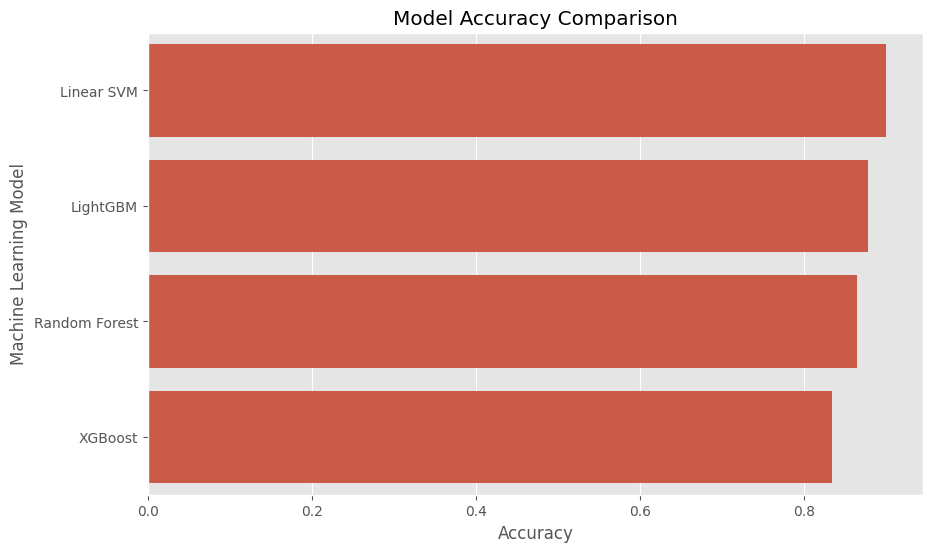

In [40]:
"""
Visualize model accuracy
"""

plt.figure(figsize=(10,6))

sns.barplot(

    data=results_df,

    x="Accuracy",

    y="Model"

)

plt.title("Model Accuracy Comparison")

plt.xlabel("Accuracy")

plt.ylabel("Machine Learning Model")

plt.show()

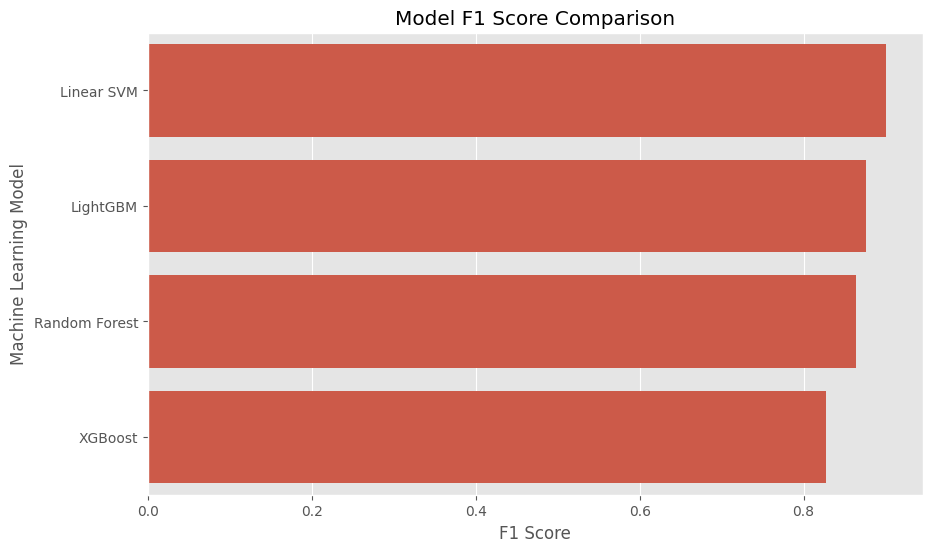

In [41]:
"""
Visualize F1 Score comparison
"""

plt.figure(figsize=(10,6))

sns.barplot(

    data=results_df,

    x="F1 Score",

    y="Model"

)

plt.title("Model F1 Score Comparison")

plt.xlabel("F1 Score")

plt.ylabel("Machine Learning Model")

plt.show()

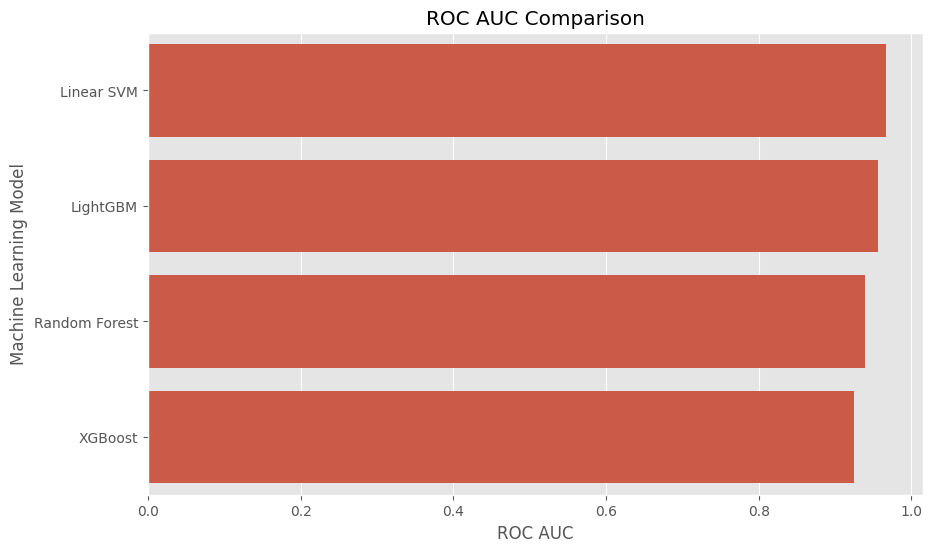

In [42]:
"""
Visualize ROC AUC comparison
"""

plt.figure(figsize=(10,6))

sns.barplot(

    data=results_df,

    x="ROC AUC",

    y="Model"

)

plt.title("ROC AUC Comparison")

plt.xlabel("ROC AUC")

plt.ylabel("Machine Learning Model")

plt.show()

## Step 11 : Hyperparameter Tuning (Markdown)

# Hyperparameter Tuning

The baseline Linear Support Vector Machine achieved the highest accuracy
among all evaluated models.

In this step, GridSearchCV is used to find the optimal hyperparameters
for the Linear SVM model.

The hyperparameters explored are:

- Regularization parameter (C)
- Loss Function

In [43]:
"""
Import GridSearchCV
"""

from sklearn.model_selection import GridSearchCV

print("GridSearchCV Imported Successfully")

GridSearchCV Imported Successfully


In [44]:
"""
Define hyperparameter search space
"""

param_grid = {

    "C": [0.01, 0.1, 1, 10],

    "loss": [

        "hinge",

        "squared_hinge"

    ]

}

print(param_grid)

{'C': [0.01, 0.1, 1, 10], 'loss': ['hinge', 'squared_hinge']}


In [45]:
"""
Create baseline Linear SVM model
"""

linear_svm = LinearSVC(

    random_state=42,

    max_iter=5000

)

In [46]:
"""
Perform hyperparameter tuning
"""

grid_search = GridSearchCV(

    estimator=linear_svm,

    param_grid=param_grid,

    scoring="f1",

    cv=5,

    n_jobs=-1,

    verbose=1

)

grid_search.fit(

    X_train,

    y_train

)

print("Grid Search Completed Successfully")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Grid Search Completed Successfully


In [47]:
"""
Display best hyperparameters
"""

print("Best Parameters\n")

print(grid_search.best_params_)

print("\nBest Cross Validation Score")

print(round(grid_search.best_score_,4))

Best Parameters

{'C': 1, 'loss': 'squared_hinge'}

Best Cross Validation Score
0.8975


In [48]:
"""
Extract best model
"""

best_svm = grid_search.best_estimator_

print(best_svm)

LinearSVC(C=1, max_iter=5000, random_state=42)


## Step 12 : Calibrated Linear SVM (Markdown)

# Calibrated Linear SVM

LinearSVC does not provide probability estimates.

CalibratedClassifierCV applies probability calibration using
Platt Scaling (Sigmoid), allowing the model to return prediction
probabilities that are useful in production systems.

In [49]:
"""
Import calibrated classifier
"""

from sklearn.calibration import CalibratedClassifierCV

print("Calibration Module Imported")

Calibration Module Imported


In [50]:
"""
Create calibrated Linear SVM
"""

calibrated_svm = CalibratedClassifierCV(

    estimator=best_svm,

    method="sigmoid",

    cv=5

)

calibrated_svm.fit(

    X_train,

    y_train

)

print("Calibrated Linear SVM Trained Successfully")

Calibrated Linear SVM Trained Successfully


In [51]:
"""
Save calibrated model
"""

joblib.dump(

    calibrated_svm,

    "best_linear_svm_calibrated.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


## Step 13 : Final Evaluation (Markdown)

# Final Evaluation

Evaluate the calibrated Linear SVM using the testing dataset.

Evaluation metrics include:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

A confusion matrix and classification report are also generated.

In [52]:
"""
Generate predictions
"""

predictions = calibrated_svm.predict(

    X_test

)

probabilities = calibrated_svm.predict_proba(

    X_test

)[:,1]

print("Prediction Completed")

Prediction Completed


In [53]:
"""
Evaluate final model
"""

from sklearn.metrics import classification_report

accuracy = accuracy_score(

    y_test,

    predictions

)

precision = precision_score(

    y_test,

    predictions

)

recall = recall_score(

    y_test,

    predictions

)

f1 = f1_score(

    y_test,

    predictions

)

roc_auc = roc_auc_score(

    y_test,

    probabilities

)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

Accuracy  : 0.9018
Precision : 0.9018
Recall    : 0.9018
F1 Score  : 0.9018
ROC AUC   : 0.9676


In [54]:
"""
Display classification report
"""

print(

    classification_report(

        y_test,

        predictions

    )

)

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      4043
           1       0.90      0.90      0.90      4041

    accuracy                           0.90      8084
   macro avg       0.90      0.90      0.90      8084
weighted avg       0.90      0.90      0.90      8084



<Figure size 600x600 with 0 Axes>

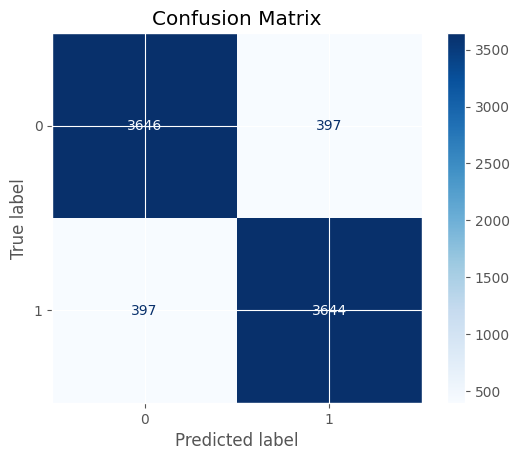

In [55]:
"""
Display confusion matrix
"""

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_estimator(

    calibrated_svm,

    X_test,

    y_test,

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.show()

In [56]:
"""
Display final model summary
"""

summary = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1,

        roc_auc

    ]

})

display(summary)

,Metric,Value
0,Accuracy,0.901781
1,Precision,0.901757
2,Recall,0.901757
3,F1 Score,0.901757
4,ROC AUC,0.967596


## Step 14 : MLflow Experiment Tracking

# MLflow Experiment Tracking

MLflow is used to track the machine learning experiment.

The following information is recorded:

- Model Name
- Hyperparameters
- Evaluation Metrics
- Trained Model
- Confusion Matrix
- Classification Report

This enables experiment reproducibility and model comparison.

In [58]:
"""
Install and import MLflow
"""

# Uncomment if MLflow is not installed
!pip install mlflow
import mlflow
import mlflow.sklearn

print("MLflow Imported Successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

In [59]:
"""
Create MLflow experiment
"""

EXPERIMENT_NAME = "InsightCart AI Generated Review Detection"

mlflow.set_experiment(EXPERIMENT_NAME)

experiment = mlflow.get_experiment_by_name(
    EXPERIMENT_NAME
)

print("Experiment Name :", experiment.name)
print("Experiment ID   :", experiment.experiment_id)

2026/08/10 16:46:19 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/10 16:46:19 INFO mlflow.store.db.utils: Updating database tables
2026/08/10 16:46:27 INFO mlflow.tracking.fluent: Experiment with name 'InsightCart AI Generated Review Detection' does not exist. Creating a new experiment.


Experiment Name : InsightCart AI Generated Review Detection
Experiment ID   : 1


In [62]:
"""
Log final model information
"""

with mlflow.start_run(run_name="Calibrated_Linear_SVM"):

    mlflow.log_param(
        "Algorithm",
        "Linear SVM"
    )

    mlflow.log_param(
        "Calibration",
        "Sigmoid"
    )

    mlflow.log_param(
        "C",
        grid_search.best_params_["C"]
    )

    mlflow.log_param(
        "Loss",
        grid_search.best_params_["loss"]
    )

    mlflow.log_metric(
        "Accuracy",
        accuracy
    )

    mlflow.log_metric(
        "Precision",
        precision
    )

    mlflow.log_metric(
        "Recall",
        recall
    )

    mlflow.log_metric(
        "F1 Score",
        f1
    )

    mlflow.log_metric(
        "ROC AUC",
        roc_auc
    )

    # Added skops_trusted_types parameter here
    mlflow.sklearn.log_model(
        sk_model=calibrated_svm,
        artifact_path="model",
        skops_trusted_types=[
            "sklearn.calibration._CalibratedClassifier",
            "sklearn.calibration._SigmoidCalibration",
        ]
    )

    print("Model Logged Successfully")

2026/08/10 16:49:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model Logged Successfully


In [63]:
"""
Display experiment summary
"""

summary = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC"

    ],

    "Value": [

        round(accuracy, 4),

        round(precision, 4),

        round(recall, 4),

        round(f1, 4),

        round(roc_auc, 4)

    ]

})

display(summary)

,Metric,Value
0,Accuracy,0.9018
1,Precision,0.9018
2,Recall,0.9018
3,F1 Score,0.9018
4,ROC AUC,0.9676


In [64]:
"""
Display MLflow tracking information
"""

print("Tracking URI")

print(mlflow.get_tracking_uri())

Tracking URI
sqlite:////content/mlflow.db
